# Model 1 — YOLO11l (CNN detector)

Strong CNN detector — predicted best on small objects (`crack`, `scratch`) and small datasets. Needs NMS at inference.

**Dataset:** CarDD (6 classes) — enhanced + class-balanced by `preprocess.ipynb`.
**Config:** `imgsz=1024`, **auto-batch** (`batch=-1`), **checkpoint every epoch** (`save_period=1`),
cosine LR, early stopping. Tuned for the small objects (`crack`/`scratch`) in this data.



## 0 · GPU check — *fails if no CUDA*

In [4]:
import torch, sys, platform
assert torch.cuda.is_available(), "No CUDA GPU found. Activate the GPU env before running."
print("Python :", sys.version.split()[0], "|", platform.system())
print("Torch  :", torch.__version__, "| CUDA", torch.version.cuda)
print("GPU    :", torch.cuda.get_device_name(0),
      "|", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB VRAM")

Python : 3.10.20 | Windows
Torch  : 2.5.1+cu121 | CUDA 12.1
GPU    : NVIDIA GeForce RTX 4080 SUPER | 17.2 GB VRAM


## 1 · Imports

In [6]:
import os, shutil, yaml
from pathlib import Path
import pandas as pd
from ultralytics import YOLO
import ultralytics
print("ultralytics", ultralytics.__version__)

ultralytics 8.4.66


## 2 · Resolve dataset paths (portable across machines)

`data_balanced.yaml` stores an absolute `path:` from the machine it was created on. This cell
finds the real `CarDD/` root on *this* machine and writes a corrected `data_local.yaml` so the
training works on the remote PC without manual edits.

In [7]:
HERE = Path.cwd()
# find the CarDD root = the folder that contains data_balanced.yaml
ROOT = None
for cand in [HERE, *HERE.parents]:
    if (cand / "data_balanced.yaml").exists():
        ROOT = cand
        break
assert ROOT is not None, "Could not find data_balanced.yaml. Keep this notebook inside CarDD/model/."

with open(ROOT / "data_balanced.yaml") as f:
    dcfg = yaml.safe_load(f)
dcfg["path"] = str(ROOT).replace("\\", "/")        # fix absolute root for THIS machine

DATA_YAML = HERE / "data_local.yaml"
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(dcfg, f, sort_keys=False, allow_unicode=True)

# sanity: confirm the referenced folders exist
for sub in ([dcfg["train"]] if isinstance(dcfg["train"], str) else dcfg["train"]) + [dcfg["val"], dcfg["test"]]:
    p = ROOT / sub
    print(("  OK " if p.exists() else "  MISSING "), p)
print("\nUsing data config:", DATA_YAML)
print(open(DATA_YAML).read())

  OK  c:\Users\AFA001\Downloads\CarDD_transfer\enhanced\train\images
  OK  c:\Users\AFA001\Downloads\CarDD_transfer\aug_train\images
  OK  c:\Users\AFA001\Downloads\CarDD_transfer\enhanced\val\images
  OK  c:\Users\AFA001\Downloads\CarDD_transfer\enhanced\test\images

Using data config: c:\Users\AFA001\Downloads\CarDD_transfer\model\data_local.yaml
path: c:/Users/AFA001/Downloads/CarDD_transfer
train:
- enhanced/train/images
- aug_train/images
val: enhanced/val/images
test: enhanced/test/images
nc: 6
names:
  0: dent
  1: scratch
  2: crack
  3: glass_shatter
  4: lamp_broken
  5: tire_flat



## 3 · Training configuration

In [8]:
MODEL_WEIGHTS = "yolo11l.pt"   # COCO-pretrained
RUN_NAME      = "01_yolo11l"
PROJECT       = str(HERE / "runs")

TRAIN_ARGS = dict(
    data        = str(DATA_YAML),
    model       = MODEL_WEIGHTS,
    imgsz       = 1024,      # high res protects small crack/scratch
    epochs      = 150,
    batch       = -1,        # AUTO-BATCH: Ultralytics picks the largest safe batch (~60% VRAM)
    device      = 0,
    patience    = 30,        # early stop if no val improvement for 50 epochs
    save        = True,
    save_period = 1,         # CHECKPOINT EVERY EPOCH -> runs/<name>/weights/epoch*.pt
    cos_lr      = True,
    close_mosaic= 15,        # disable mosaic for last 15 epochs (protects tiny boxes)
    fliplr      = 0.5,
    flipud      = 0.0,       # NO vertical flip (vertical structure in the data)
    seed        = 42,
    plots       = True,
    val         = True,
    cache       = False,     # set "ram"/"disk" if you have spare memory for speed
    workers     = 8,
    optimizer   = "auto",
    amp         = True,
    project     = PROJECT,
    name        = RUN_NAME,
    exist_ok    = False,
)
for k, v in TRAIN_ARGS.items():
    print(f"  {k:12s}: {v}")

  data        : c:\Users\AFA001\Downloads\CarDD_transfer\model\data_local.yaml
  model       : yolo11l.pt
  imgsz       : 1024
  epochs      : 150
  batch       : -1
  device      : 0
  patience    : 30
  save        : True
  save_period : 1
  cos_lr      : True
  close_mosaic: 15
  fliplr      : 0.5
  flipud      : 0.0
  seed        : 42
  plots       : True
  val         : True
  cache       : False
  workers     : 8
  optimizer   : auto
  amp         : True
  project     : c:\Users\AFA001\Downloads\CarDD_transfer\model\runs
  name        : 01_yolo11l
  exist_ok    : False


## 4 · Train

Loads COCO-pretrained `yolo11l.pt` and fine-tunes on CarDD.
- **Auto-batch** picks the batch size for the remote GPU automatically — no manual tuning.
- A checkpoint is written **every epoch**; `best.pt` (best val mAP) and `last.pt` are always kept.
- Interrupted? Re-run with `resume=True` 


In [9]:
model = YOLO(MODEL_WEIGHTS)
results = model.train(**{k: v for k, v in TRAIN_ARGS.items() if k != "model"})
SAVE_DIR = Path(results.save_dir)
print("\nTraining done. Artifacts in:", SAVE_DIR)
print("Best weights:", SAVE_DIR / "weights" / "best.pt")

Ultralytics 8.4.66  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=c:\Users\AFA001\Downloads\CarDD_transfer\model\data_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=01_yolo11l, nbs=64, nms=False, opset=None, optimize=

## 5 · Evaluate `best.pt` on the held-out **test** split

In [10]:
best = YOLO(str(SAVE_DIR / "weights" / "best.pt"))
metrics = best.val(data=str(DATA_YAML), split="test", imgsz=1024, plots=True)

print(f"\nTEST  mAP50-95: {metrics.box.map:.4f}")
print(f"TEST  mAP50   : {metrics.box.map50:.4f}")
print(f"TEST  mAP75   : {metrics.box.map75:.4f}")

names = metrics.names
rows = []
for i, c in enumerate(metrics.box.ap_class_index):
    rows.append({"class": names[c],
                 "AP50":     round(float(metrics.box.ap50[i]), 4),
                 "AP50-95":  round(float(metrics.box.ap[i]), 4),
                 "precision":round(float(metrics.box.p[i]), 4),
                 "recall":   round(float(metrics.box.r[i]), 4)})
per_class = pd.DataFrame(rows).sort_values("AP50-95")
display(per_class)
per_class.to_csv(SAVE_DIR / "test_per_class.csv", index=False)
print("Saved per-class metrics ->", SAVE_DIR / "test_per_class.csv")

Ultralytics 8.4.66  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11l summary (fused): 191 layers, 25,283,938 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 80.031.9 MB/s, size: 312.3 KB)
val: Scanning C:\Users\AFA001\Downloads\CarDD_transfer\enhanced\test\labels... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 970.8it/s 0.4s0.1s
val: New cache created: C:\Users\AFA001\Downloads\CarDD_transfer\enhanced\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.6it/s 5.2s0.2s
                   all        374        785      0.795      0.668      0.725      0.557
                  dent        157        236      0.704      0.503      0.572      0.344
               scratch        183        307      0.634      0.554      0.578      0.309
                 crack         48         70        0.6      0.471      0.445     

,class,AP50,AP50-95,precision,recall
2,crack,0.4450,0.2530,0.6002,0.4714
1,scratch,0.5777,0.3087,0.6341,0.5537
0,dent,0.5722,0.3439,0.7038,0.5034
4,lamp_broken,0.8471,0.7163,0.9618,0.7101
5,tire_flat,0.9459,0.8593,0.9378,0.8125
3,glass_shatter,0.9601,0.8600,0.9316,0.9577


Saved per-class metrics -> C:\Users\AFA001\Downloads\CarDD_transfer\model\runs\01_yolo11l\test_per_class.csv


## 6 · Show training/result plots

results.png


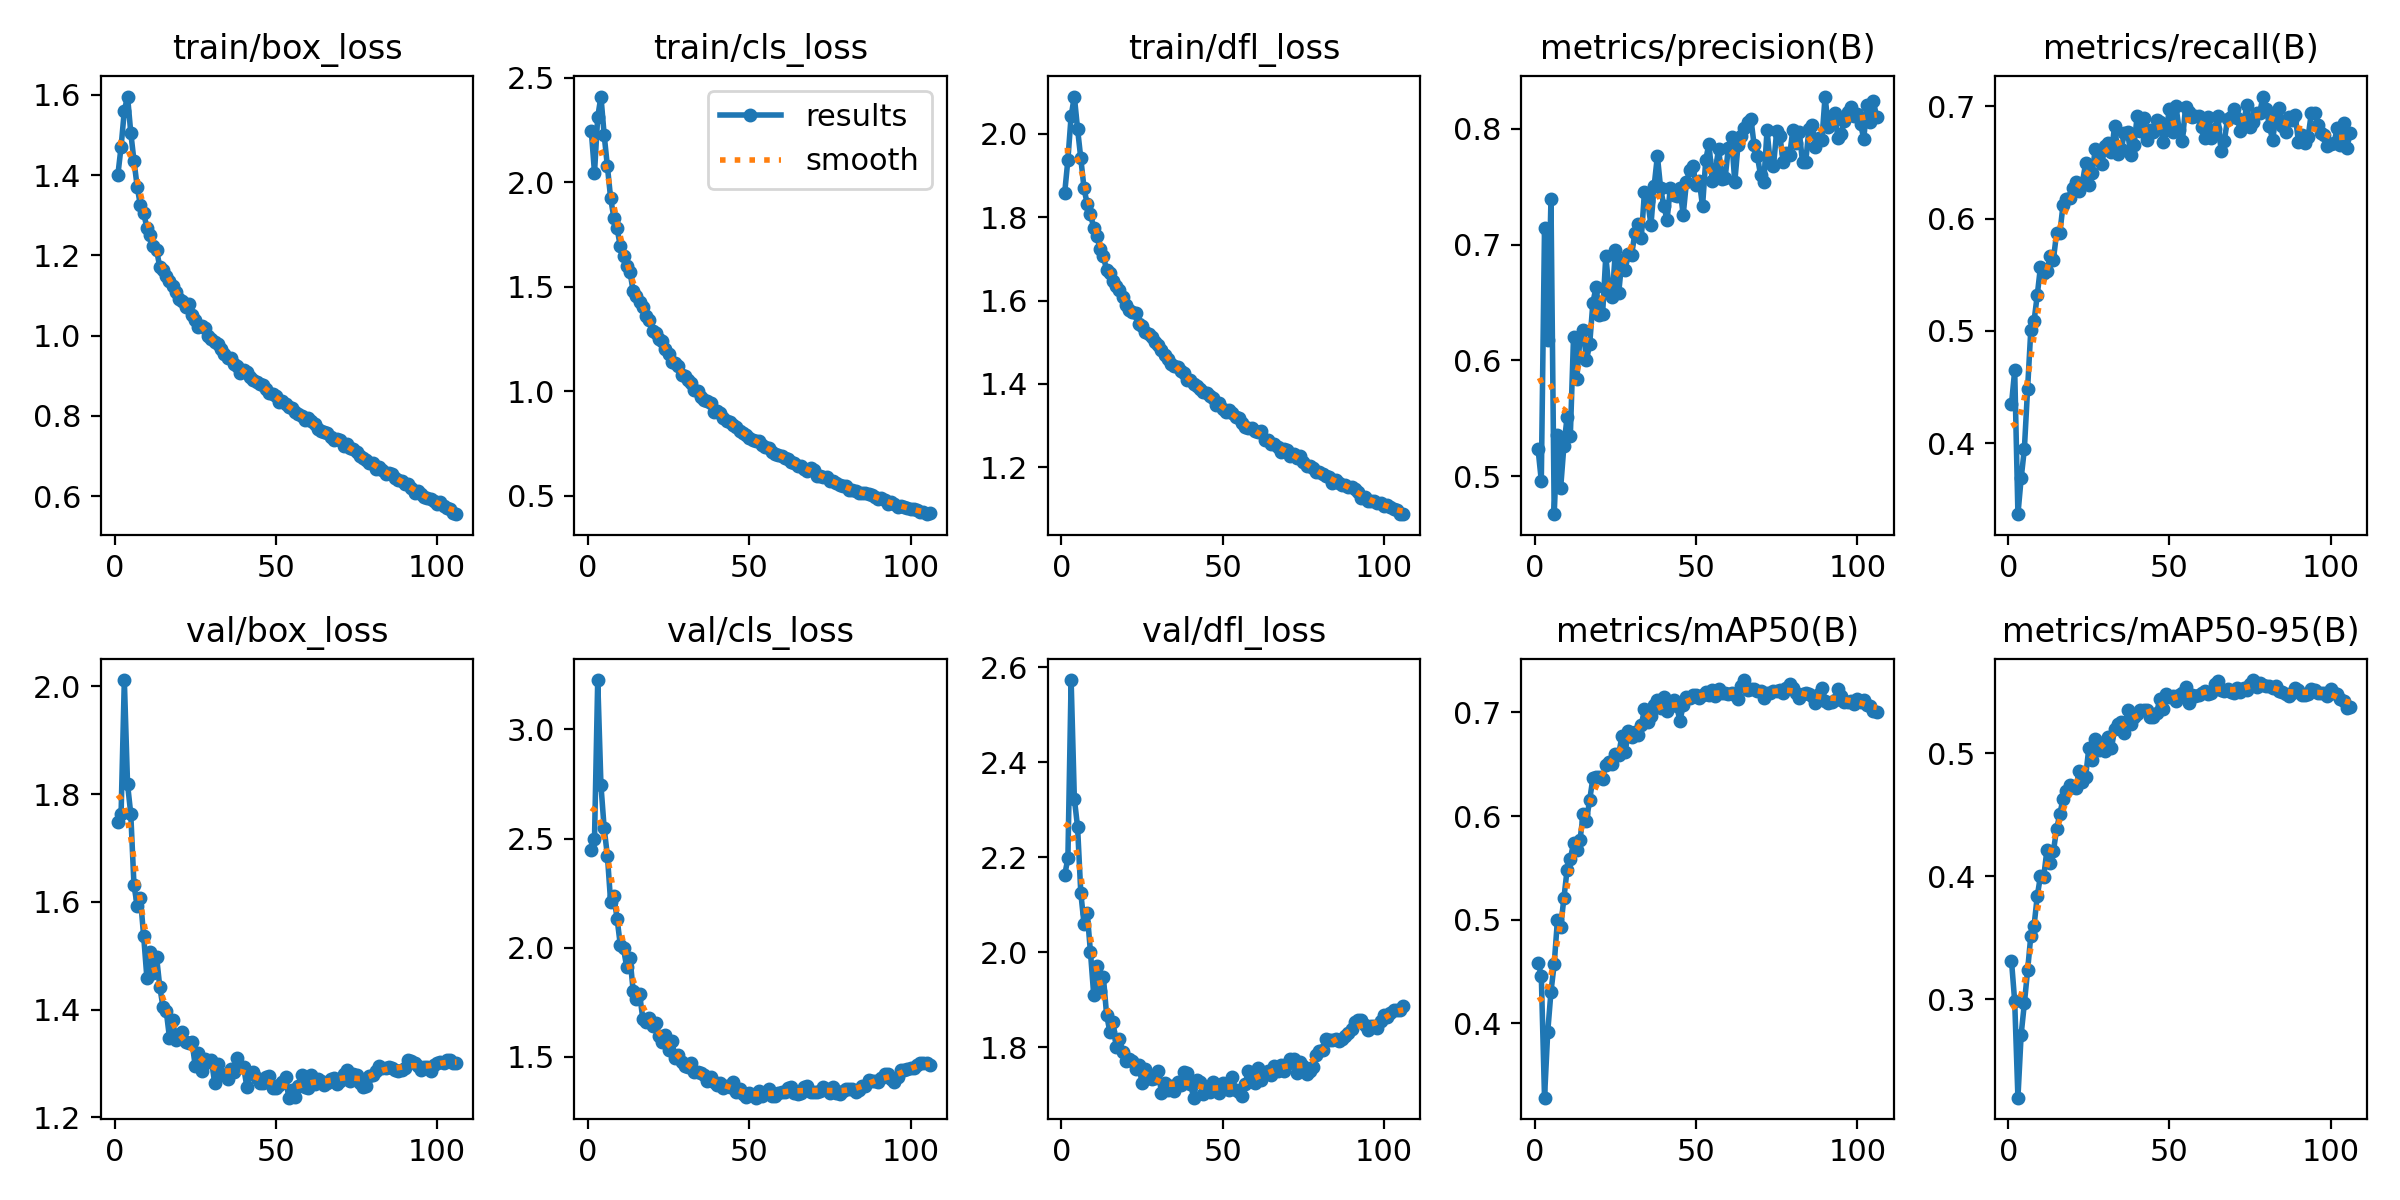

confusion_matrix_normalized.png


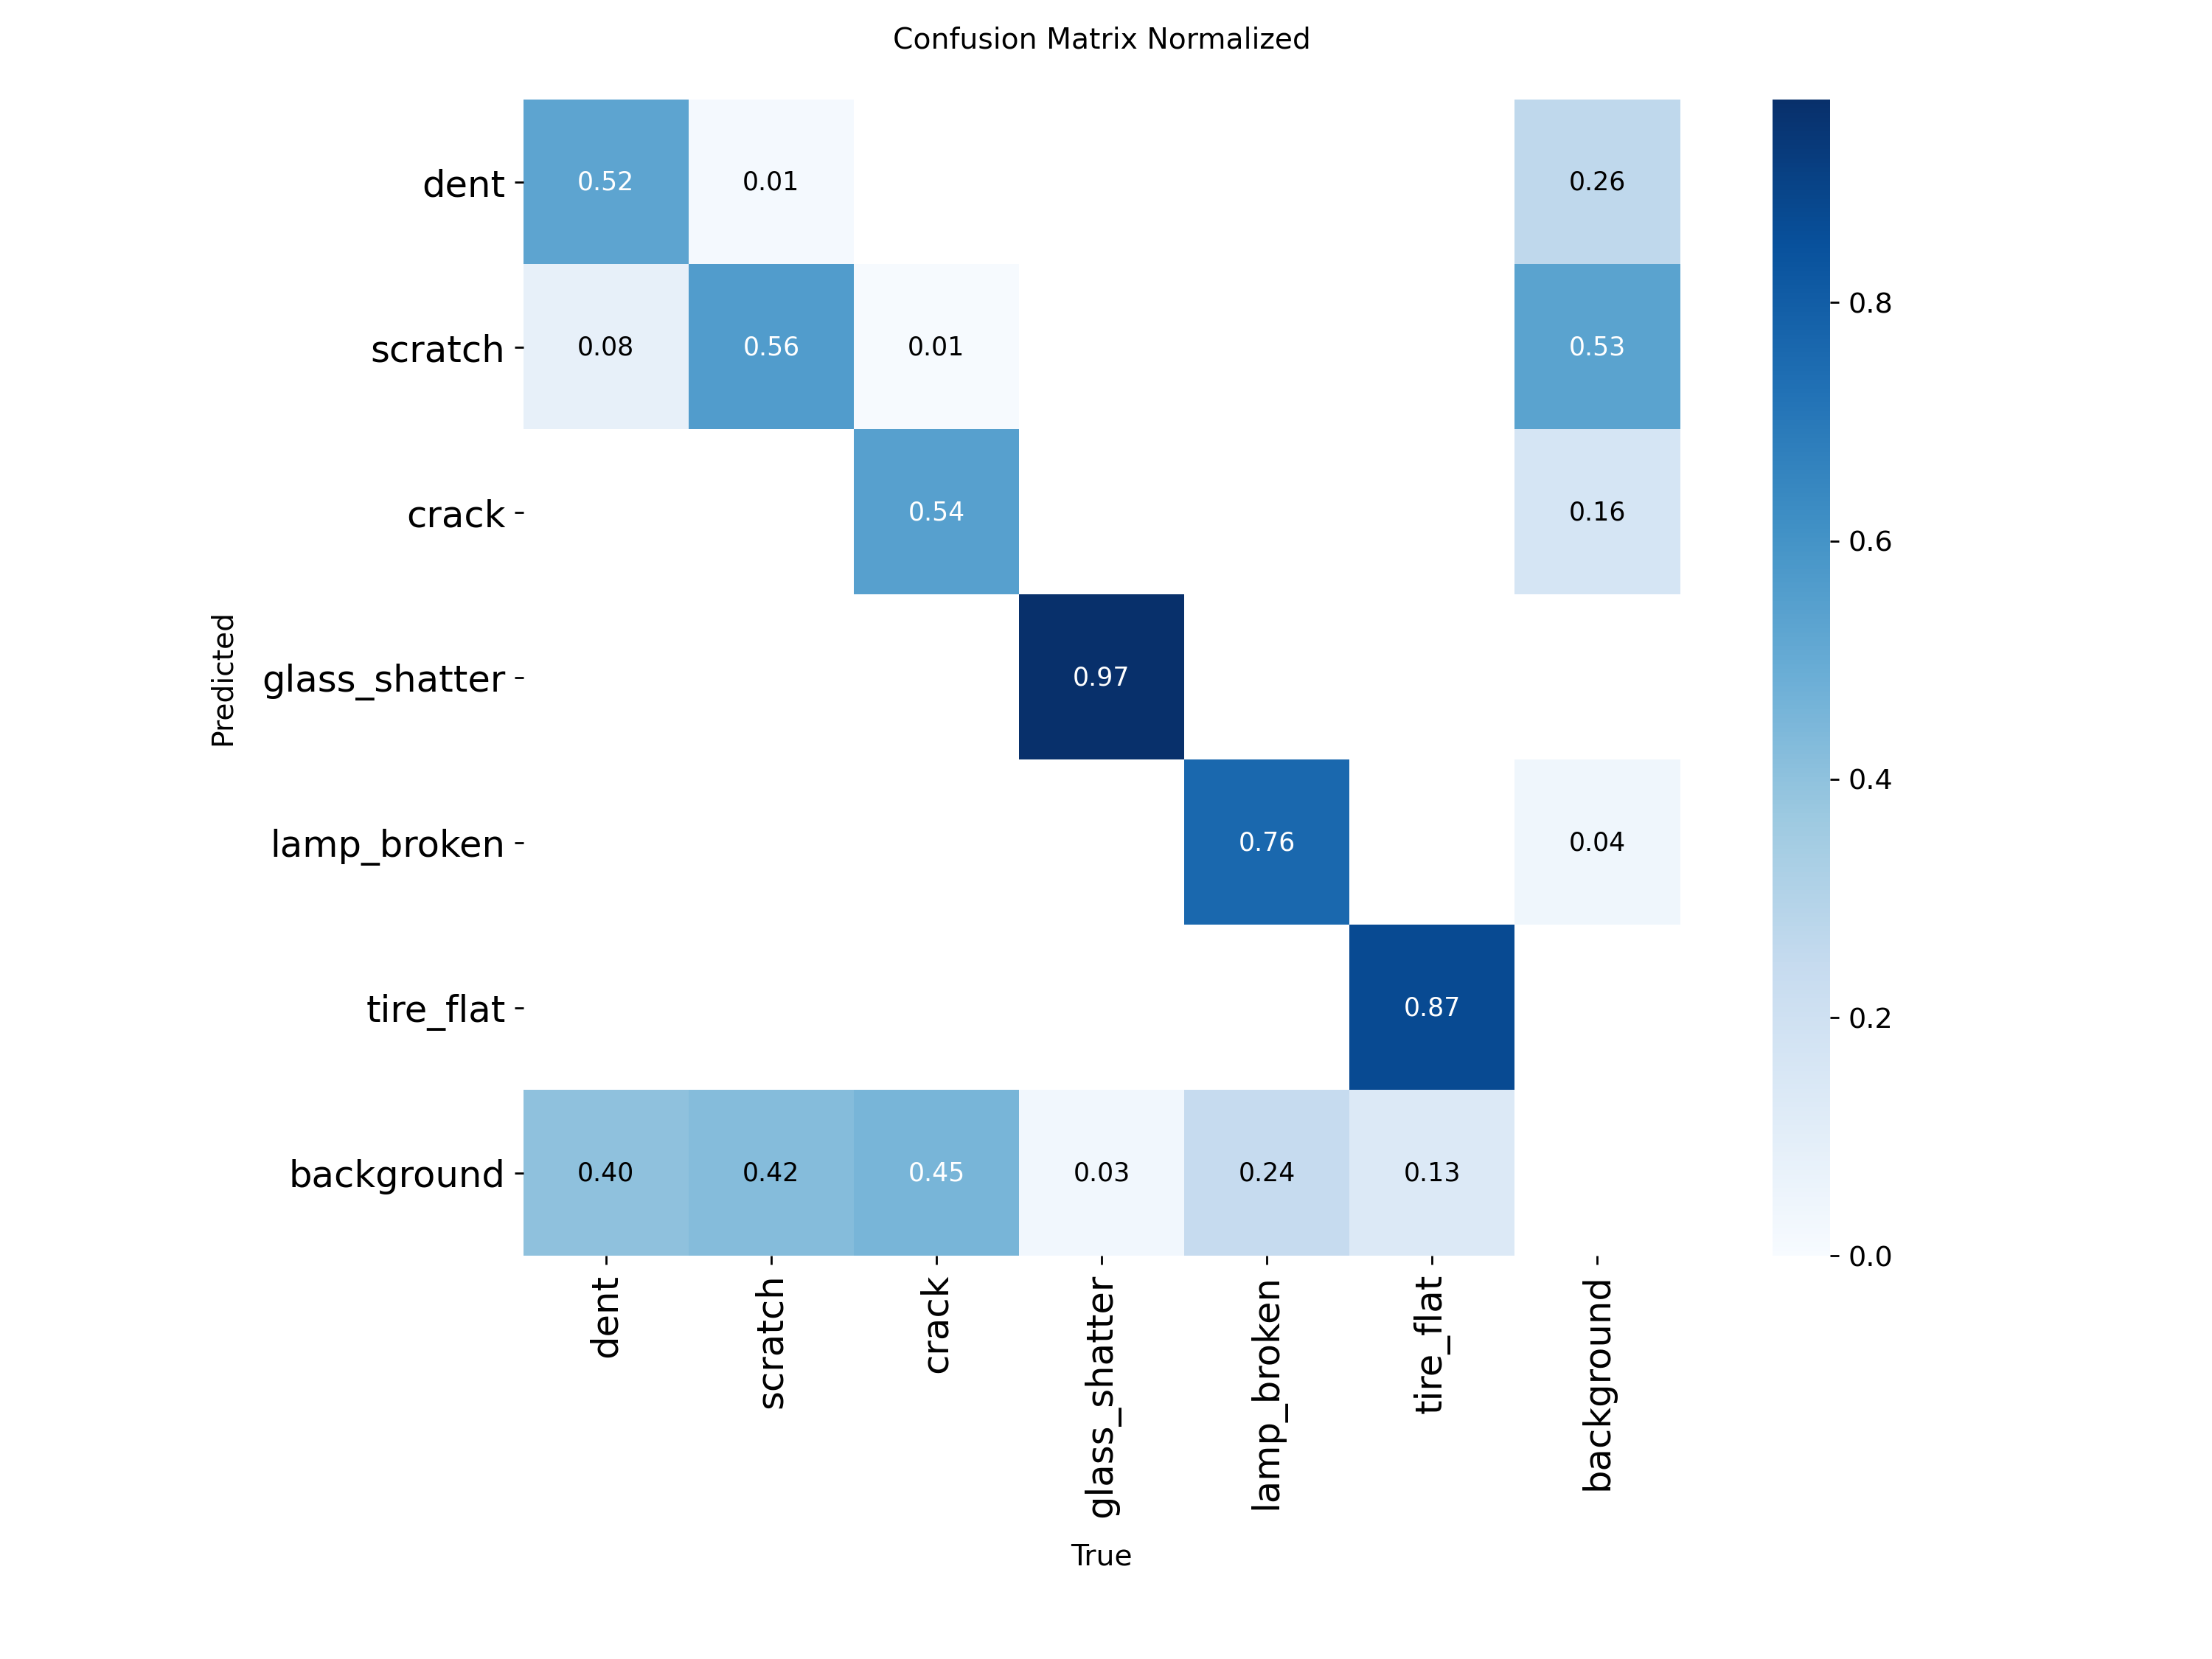

val_batch0_pred.jpg


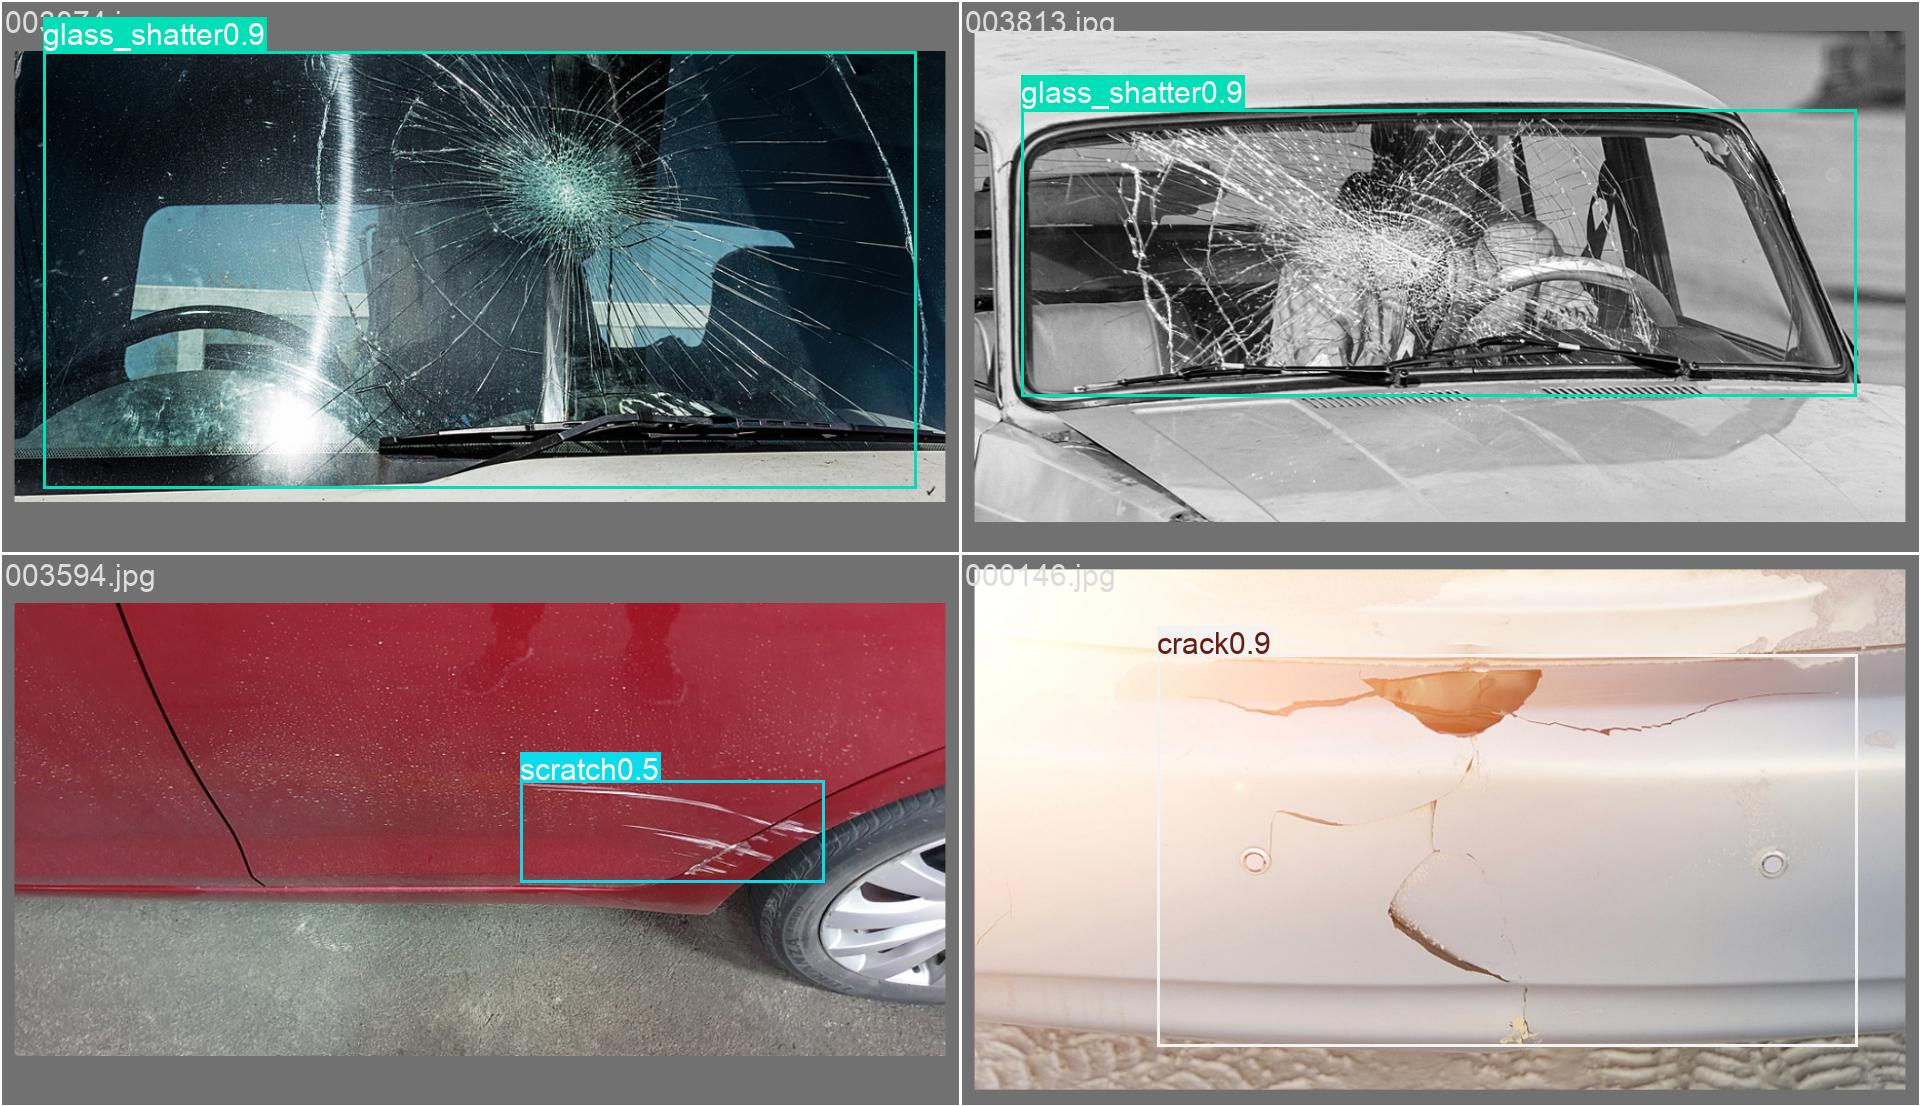

In [11]:
from IPython.display import Image as IPyImage, display
for fn in ["results.png", "confusion_matrix_normalized.png", "PR_curve.png", "val_batch0_pred.jpg"]:
    f = SAVE_DIR / fn
    if f.exists():
        print(fn); display(IPyImage(filename=str(f)))